---
title: Homework Module 4 — Classical Bit Demodulator (BPSK)
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Executable walkthrough of `HW4_591.py` / `HW4_591.ipynb`. We simulate a classical
**BPSK** communication link:

1. Generate random bits and map them to phases $0$ or $\pi$.
2. Form the clean carrier samples $x_i(t)=\cos(\omega t + \phi_i)$.
3. Add AWGN at the specified SNR to get $y_i(t)$.
4. Recover each bit by least-squares projection onto $\{\cos\omega t,\sin\omega t\}$.
5. Report Monte Carlo **bit-error rate (BER)**.

Debug prints that were previously commented are **enabled**, and annotated plots show
waveforms, the design basis, and the feature plane used for decisions.


## Imports


In [1]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Reproducible Monte Carlo for website builds
np.random.seed(42)


## Parameter setup

| Symbol | Meaning | Value in this notebook |
|--------|---------|------------------------|
| $N$ | samples per bit | 3 |
| $N_B$ | Monte Carlo bits | 100000 |
| SNR | linear SNR | 1 (0 dB) |
| $\omega$ | $2\pi/N$ | one cycle over the $N$ samples |
| $\sigma$ | noise std | $\sqrt{0.5/\mathrm{SNR}}$ |


In [2]:
# ================================================
# PARAMETER SETUP FOR CLASSICAL BIT DEMODULATOR
# ================================================
number_of_samples = 3
number_of_bits = 100000
SNR = 1  # 0 dB

omega = 2 * np.pi / number_of_samples  # rad/sec
print(f"Omega = {omega:.4f} [rad/sec]")

freq = omega / (2 * np.pi)
print(f"Frequency = {freq:.4f} [Hz]")

sigma = np.sqrt(0.5 / SNR)
print(f"Sigma = {sigma:.4f}")
print(f"N = {number_of_samples}, N_B = {number_of_bits}, SNR = {SNR}")


Omega = 2.0944 [rad/sec]
Frequency = 0.3333 [Hz]
Sigma = 0.7071
N = 3, N_B = 100000, SNR = 1


## Transmitter: time grid and random bits

Sample indices $t=0,1,\ldots,N-1$ and a fair Bernoulli bit sequence of length $N_B$.


In [3]:
# ================================================
# SIGNAL GENERATION — TIME AXIS & RANDOM BITS
# ================================================
time_array = np.arange(number_of_samples)
bits_array = np.random.randint(0, 2, size=number_of_bits)

print("time_array =", time_array)
print("bits_array (first 20) =", bits_array[:20])
print("bits_array shape =", bits_array.shape)
print("fraction of ones =", bits_array.mean())


time_array = [0 1 2]
bits_array (first 20) = [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
bits_array shape = (100000,)
fraction of ones = 0.50063


## Phase mapping (BPSK)

$$\phi_i = b_i\cdot\pi \quad\Rightarrow\quad b_i=0 \to \phi=0,\quad b_i=1\to\phi=\pi.$$


In [4]:
# ================================================
# SIGNAL GENERATION — PHASE MAPPING
# ================================================
phase_array = bits_array * np.pi
print("phase_array (first 20) =", phase_array[:20])


phase_array (first 20) = [0.         3.14159265 0.         0.         0.         3.14159265
 0.         0.         0.         3.14159265 0.         0.
 0.         0.         3.14159265 0.         3.14159265 3.14159265
 3.14159265 0.        ]


## Clean transmitted waveforms

Vectorized construction of
$$x_i(t)=\cos(\omega t+\phi_i),\qquad \text{shape }(N_B,N).$$


In [5]:
# ================================================
# SIGNAL GENERATION — TRANSMITTED SIGNAL MATRIX
# ================================================
x_of_t = np.cos(omega * time_array + phase_array[:, np.newaxis])
print("x_of_t shape =", x_of_t.shape)
print("x_of_t[0:3] =")
print(x_of_t[0:3])


x_of_t shape = (100000, 3)
x_of_t[0:3] =
[[ 1.  -0.5 -0.5]
 [-1.   0.5  0.5]
 [ 1.  -0.5 -0.5]]


## Additive white Gaussian noise

Each sample of $n_i(t)$ is $\mathcal{N}(0,\sigma^2)$ with $\sigma=\sqrt{0.5/\mathrm{SNR}}$.


In [6]:
# ================================================
# SIGNAL GENERATION — NOISE GENERATION
# ================================================
noise_array = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=(number_of_bits, number_of_samples),
)
print("noise_array[0:5] =")
print(noise_array[0:5])
print("noise empirical std =", noise_array.std())


noise_array[0:5] =
[[-0.01347986  0.85368175  0.44214853]
 [-0.56900108  1.26368002 -1.08599332]
 [ 0.19494729 -0.5818532  -1.05162668]
 [-0.80198708 -0.0348176   0.24729417]
 [ 0.74877788  1.04371543  0.19635446]]


noise empirical std = 0.7071616876455934


## Received signals

$$y_i(t)=x_i(t)+n_i(t).$$


In [7]:
# ================================================
# SIGNAL GENERATION — RECEIVED SIGNAL MATRIX
# ================================================
y_of_t = x_of_t + noise_array
print("y_of_t[0:5] =")
print(y_of_t[0:5])
print("y_of_t shape =", y_of_t.shape)


y_of_t[0:5] =
[[ 0.98652014  0.35368175 -0.05785147]
 [-1.56900108  1.76368002 -0.58599332]
 [ 1.19494729 -1.0818532  -1.55162668]
 [ 0.19801292 -0.5348176  -0.25270583]
 [ 1.74877788  0.54371543 -0.30364554]]
y_of_t shape = (100000, 3)


### Annotated plot — clean vs noisy waveforms

Show the first few bits: ideal carrier samples and the noisy observations used by the demodulator.


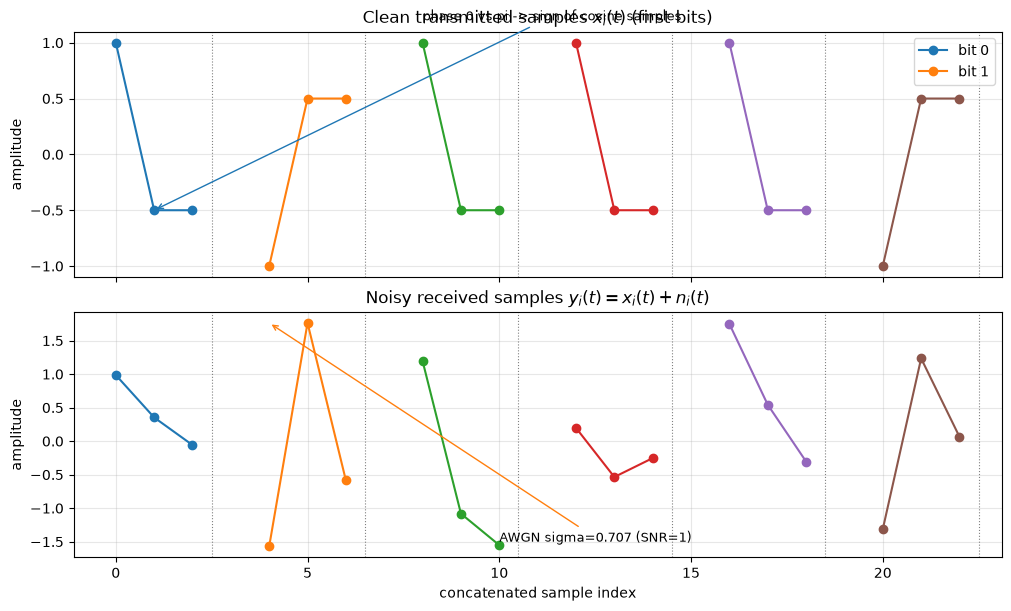

In [8]:
# Pick a few bits for illustration
show_bits = 6
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

for i in range(show_bits):
    offset = i * (number_of_samples + 1)
    t_local = time_array + offset
    axes[0].plot(t_local, x_of_t[i], "o-", label=f"bit {bits_array[i]}" if i < 2 else None)
    axes[1].plot(t_local, y_of_t[i], "o-", label=f"bit {bits_array[i]}" if i < 2 else None)
    axes[0].axvline(offset + number_of_samples - 0.5, color="gray", ls=":", lw=0.8)
    axes[1].axvline(offset + number_of_samples - 0.5, color="gray", ls=":", lw=0.8)

axes[0].set_title("Clean transmitted samples $x_i(t)$ (first bits)")
axes[0].set_ylabel("amplitude")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")
axes[0].annotate(
    "phase 0 vs pi -> sign of cosine samples",
    xy=(1, x_of_t[0, 1]),
    xytext=(8, 1.2),
    arrowprops=dict(arrowstyle="->", color="C0"),
    fontsize=9,
)

axes[1].set_title("Noisy received samples $y_i(t)=x_i(t)+n_i(t)$")
axes[1].set_xlabel("concatenated sample index")
axes[1].set_ylabel("amplitude")
axes[1].grid(True, alpha=0.3)
axes[1].annotate(
    f"AWGN sigma={sigma:.3f} (SNR={SNR})",
    xy=(4, y_of_t[1, 1]),
    xytext=(10, -1.5),
    arrowprops=dict(arrowstyle="->", color="C1"),
    fontsize=9,
)
plt.show()


## Design matrix $H$ for least-squares demodulation

Model each received block as
$$y \approx A\cos(\omega t)+B\sin(\omega t)= H\begin{bmatrix}A\\B\end{bmatrix},$$
with
$$H=\begin{bmatrix}\cos\omega t_k & \sin\omega t_k\end{bmatrix}_{k=0}^{N-1}.$$


In [9]:
# ================================================
# DECODING — DESIGN MATRIX
# ================================================
h = np.zeros((number_of_samples, 2))
h[:, 0] = np.cos(2 * np.pi * freq * time_array)
h[:, 1] = np.sin(2 * np.pi * freq * time_array)
print("Design matrix h =")
print(h)

# Precompute b = (H^T H)^{-1}
b = inv(np.dot(h.transpose(), h))
print("b = (H^T H)^{-1} =")
print(b)


Design matrix h =
[[ 1.         0.       ]
 [-0.5        0.8660254]
 [-0.5       -0.8660254]]
b = (H^T H)^{-1} =
[[ 6.66666667e-01 -1.72701359e-16]
 [-1.72701359e-16  6.66666667e-01]]


### Plot the known basis functions (columns of $H$)


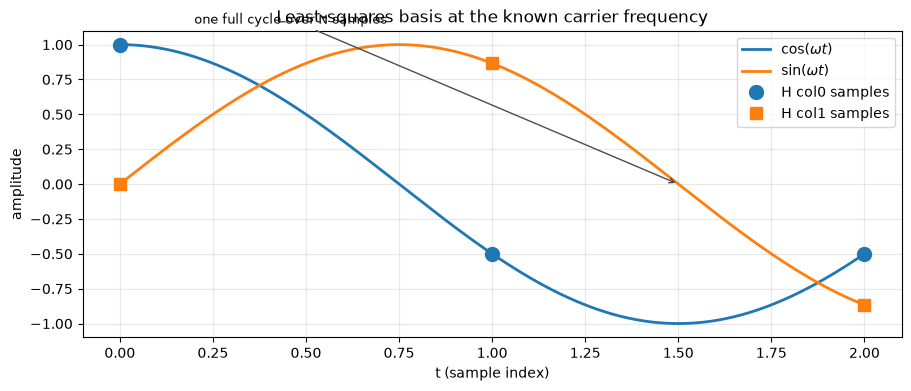

In [10]:
t_dense = np.linspace(0, number_of_samples - 1, 200)
fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
ax.plot(t_dense, np.cos(omega * t_dense), label=r"$\cos(\omega t)$", lw=2)
ax.plot(t_dense, np.sin(omega * t_dense), label=r"$\sin(\omega t)$", lw=2)
ax.plot(time_array, h[:, 0], "o", color="C0", markersize=10, label="H col0 samples")
ax.plot(time_array, h[:, 1], "s", color="C1", markersize=9, label="H col1 samples")
ax.set_title("Least-squares basis at the known carrier frequency")
ax.set_xlabel("t (sample index)")
ax.set_ylabel("amplitude")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
ax.annotate("one full cycle over N samples", xy=(1.5, 0), xytext=(0.2, 1.15),
            arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9)
plt.show()


## Classical demodulator loop

For each bit:
1. $a = H^\top y_i$
2. $c = b\,a = [A,B]^\top$
3. Decide $\hat b_i = 1$ if $A<0$, else $0$ (sign of the cosine coefficient).


In [11]:
# ================================================
# DECODING — CLASSICAL BIT DEMODULATOR
# ================================================
bits_array_hat = np.zeros(number_of_bits, dtype=int)
A_coeffs = np.zeros(number_of_bits)
B_coeffs = np.zeros(number_of_bits)

for i in range(number_of_bits):
    yi = y_of_t[i, :]
    a = np.dot(h.transpose(), yi)
    c = np.dot(b, a)
    A = c[0]
    B = c[1]
    A_coeffs[i] = A
    B_coeffs[i] = B
    bits_array_hat[i] = 1 if A < 0 else 0

print("bits_array (first 20)     =", bits_array[:20])
print("bits_array_hat (first 20) =", bits_array_hat[:20])
print("A_coeffs (first 10) =", A_coeffs[:10])
print("B_coeffs (first 10) =", B_coeffs[:10])


bits_array (first 20)     = [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
bits_array_hat (first 20) = [0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 0]
A_coeffs (first 10) = [ 0.55907    -1.43856295  1.67445815  0.39451642  1.08582862 -1.30894966
 -0.28555605  0.01299707  1.08657846 -1.46570113]
B_coeffs (first 10) = [ 0.23759882  1.35658454  0.27122384 -0.1628773   0.48922408  0.67510337
 -0.15713491  0.56247259 -0.62624262  0.16059377]


### Annotated feature plane $(A,B)$

Each point is one demodulated bit. The decision boundary is the $A=0$ line: left half-plane → bit 1, right → bit 0.


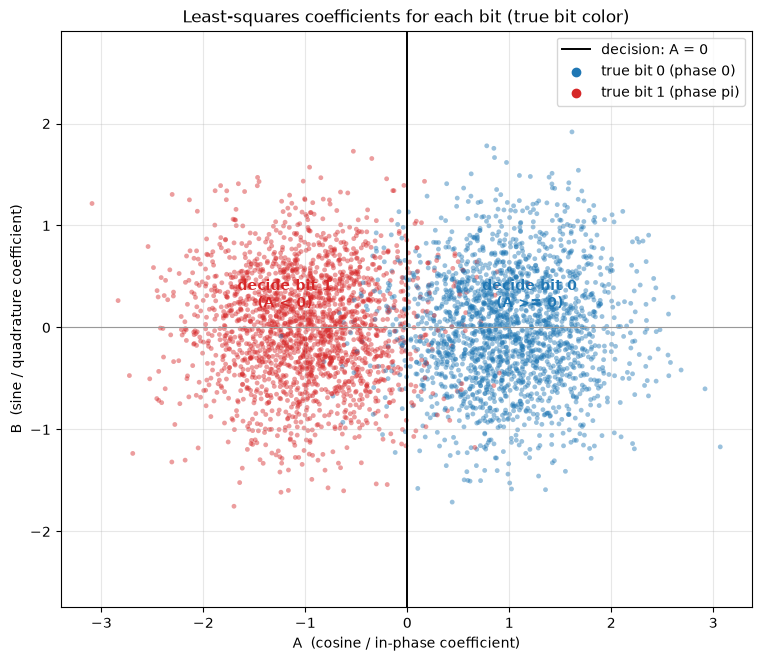

In [12]:
# Subsample for a readable scatter plot
idx = np.random.choice(number_of_bits, size=min(4000, number_of_bits), replace=False)
fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
colors = np.where(bits_array[idx] == 0, "C0", "C3")
ax.scatter(A_coeffs[idx], B_coeffs[idx], c=colors, s=12, alpha=0.45, edgecolors="none")
ax.axvline(0, color="k", lw=1.4, label="decision: A = 0")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("A  (cosine / in-phase coefficient)")
ax.set_ylabel("B  (sine / quadrature coefficient)")
ax.set_title("Least-squares coefficients for each bit (true bit color)")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="datalim")
ax.scatter([], [], c="C0", label="true bit 0 (phase 0)")
ax.scatter([], [], c="C3", label="true bit 1 (phase pi)")
ax.legend(loc="upper right")
ax.annotate("decide bit 0\n(A >= 0)", xy=(1.2, 0.2), fontsize=10, color="C0",
            ha="center", fontweight="bold")
ax.annotate("decide bit 1\n(A < 0)", xy=(-1.2, 0.2), fontsize=10, color="C3",
            ha="center", fontweight="bold")
plt.show()


## Bit-error rate

$$\mathrm{BER}=\frac{1}{N_B}\sum_{i=1}^{N_B}\mathbf{1}\{\hat b_i\neq b_i\}.$$


In [13]:
# ================================================
# PERFORMANCE EVALUATION — BER
# ================================================
errors = bits_array != bits_array_hat
BER = np.sum(errors) / number_of_bits
print(f"{BER:.6f}")
print(f"Bit errors: {np.sum(errors)} / {number_of_bits}")
print(f"BER = {BER:.6f}  ({100*BER:.3f} %)")


0.041560
Bit errors: 4156 / 100000
BER = 0.041560  (4.156 %)


### Error locations among the first bits (sanity view)


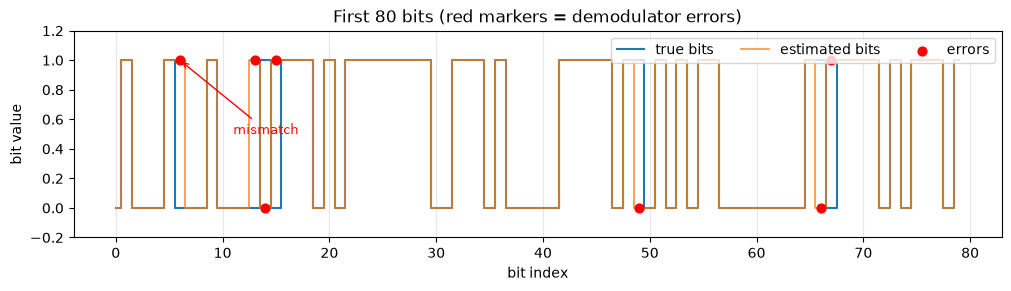

In [14]:
n_show = 80
fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
ax.step(np.arange(n_show), bits_array[:n_show], where="mid", label="true bits", lw=1.5)
ax.step(np.arange(n_show), bits_array_hat[:n_show], where="mid", label="estimated bits", lw=1.2, alpha=0.85)
err_idx = np.where(errors[:n_show])[0]
ax.scatter(err_idx, bits_array_hat[err_idx], c="red", s=40, zorder=5, label="errors")
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("bit index")
ax.set_ylabel("bit value")
ax.set_title(f"First {n_show} bits (red markers = demodulator errors)")
ax.grid(True, axis="x", alpha=0.3)
ax.legend(loc="upper right", ncol=3)
if len(err_idx):
    ax.annotate("mismatch", xy=(err_idx[0], bits_array_hat[err_idx[0]]),
                xytext=(err_idx[0] + 5, 0.5),
                arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=9)
plt.show()


## Takeaways

- BPSK puts information in the **sign of the in-phase coefficient** $A$ after LS fitting.
- At SNR = 0 dB with only $N=3$ samples/bit, BER is non-negligible — noise can flip the sign of $A$.
- Precomputing $(H^\top H)^{-1}$ keeps the Monte Carlo loop cheap for large $N_B$.
- Original script: `hw4.py` / `HW4_591.py`.
